# Data Aggregation and Grouping

In [1]:
import pandas as pd

## The groupby method

This method will do three things: split + apply + combine

In [2]:
# load the drinks dataset
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/drinks.csv'
drinks = pd.read_csv(url)

In [3]:
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,Asia
1,Albania,89,132,54,4.9,Europe
2,Algeria,25,0,14,0.7,Africa
3,Andorra,245,138,312,12.4,Europe
4,Angola,217,57,45,5.9,Africa


In [4]:
# find the average beer servings across the entire dataset

drinks.beer_servings.mean()

106.16062176165804

In [5]:
# find the average beer servings just for countries in Africa

drinks.loc[drinks.continent=='Africa'].beer_servings.mean()

61.471698113207545

In [6]:
# find the average beer servings for each continent

drinks.groupby('continent').beer_servings.mean()

continent
Africa            61.471698
Asia              37.045455
Europe           193.777778
North America    145.434783
Oceania           89.687500
South America    175.083333
Name: beer_servings, dtype: float64

In [7]:
# find the max value of 'beer.servings for each continent'

drinks.groupby('continent').beer_servings.max()

continent
Africa           376
Asia             247
Europe           361
North America    285
Oceania          306
South America    333
Name: beer_servings, dtype: int64

In [8]:
# you can use your own functions
def peak_to_peak(group):
    return group.max()-group.min()

drinks.groupby('continent').beer_servings.apply(peak_to_peak)

continent
Africa           376
Asia             247
Europe           361
North America    284
Oceania          306
South America    240
Name: beer_servings, dtype: int64

In [9]:
drinks.groupby('continent')[['beer_servings','spirit_servings','wine_servings']].apply(peak_to_peak)

,beer_servings,spirit_servings,wine_servings
continent,,,
Africa,376,152,233
Asia,247,326,123
Europe,361,373,370
North America,284,370,99
Oceania,306,254,212
South America,240,277,220


In [10]:
# top 5 wine_servings countries by continent
def top5(group):
    return group.sort_values(by='wine_servings', ascending=False).head(5)

drinks.groupby('continent').apply(top5)

country  beer_servings  spirit_servings  \
continent                                                                
Africa        55     Equatorial Guinea             92                0   
              148  Sao Tome & Principe             56               38   
              159         South Africa            225               76   
              62                 Gabon            347               98   
              152           Seychelles            157               25   
Asia          92                  Laos             62                0   
              141   Russian Federation            247              326   
              177         Turkmenistan             19               71   
              94               Lebanon             20               55   
              167                Syria              5               35   
Europe        61                France            127              151   
              136             Portugal            194               67   
              3                Andorra            245              138   
              166          Switzerland            185              100   
              48               Denmark            224               81   
North America 32                Canada            240              122   
              184                  USA            249              158   
              144            St. Lucia            171              315   
              11               Bahamas            122              176   
              5      Antigua & Barbuda            102              128   
Oceania       8              Australia            261               72   
              121          New Zealand            203               79   
              40          Cook Islands              0              254   
              146                Samoa            105               18   
              129                Palau            306               63   
South America 6              Argentina            193               25   
              185              Uruguay            115               35   
              35                 Chile            130              124   
              132             Paraguay            213              117   
              133                 Peru            163              160   

                   wine_servings  total_litres_of_pure_alcohol      continent  
continent                                                                      
Africa        55             233                           5.8         Africa  
              148            140                           4.2         Africa  
              159             81                           8.2         Africa  
              62              59                           8.9         Africa  
              152             51                           4.1         Africa  
Asia          92             123                           6.2           Asia  
              141             73                          11.5           Asia  
              177             32                           2.2           Asia  
              94              31                           1.9           Asia  
              167             16                           1.0           Asia  
Europe        61             370                          11.8         Europe  
              136            339                          11.0         Europe  
              3              312                          12.4         Europe  
              166            280                          10.2         Europe  
              48             278                          10.4         Europe  
North America 32             100                           8.2  North America  
              184             84                           8.7  North America  
              144             71                          10.1  North America  
              11              51                           6.3

## Unstack

In [11]:
# load tips dataset
path= 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/tips.csv'
tips=pd.read_csv(path)

In [12]:
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [13]:
# add tip percentage
tips['pct_tip'] = 100*tips.tip/tips.total_bill

In [14]:
tips

,total_bill,tip,smoker,day,time,size,pct_tip
0,16.99,1.01,No,Sun,Dinner,2,5.944673
1,10.34,1.66,No,Sun,Dinner,3,16.054159
2,21.01,3.50,No,Sun,Dinner,3,16.658734
3,23.68,3.31,No,Sun,Dinner,2,13.978041
4,24.59,3.61,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,No,Sat,Dinner,2,9.820426


In [15]:
# mean tip percentage by day and smoker / nonsmoker

tips.groupby(['day','smoker']).pct_tip.mean() #this has a multi-index

day   smoker
Fri   No        15.165044
      Yes       17.478305
Sat   No        15.804766
      Yes       14.790607
Sun   No        16.011294
      Yes       18.725032
Thur  No        16.029808
      Yes       16.386327
Name: pct_tip, dtype: float64

In [16]:
#unstack removes our multi-inexing

tips.groupby(['day','smoker']).pct_tip.mean().unstack(level=1)

smoker,No,Yes
day,,
Fri,15.165044,17.478305
Sat,15.804766,14.790607
Sun,16.011294,18.725032
Thur,16.029808,16.386327


## pivot table

In [17]:
tips.pivot_table(values='pct_tip',index ='day',columns='smoker', aggfunc = 'mean')

smoker,No,Yes
day,,
Fri,15.165044,17.478305
Sat,15.804766,14.790607
Sun,16.011294,18.725032
Thur,16.029808,16.386327


Find mean 'pct_tip' value by 'time', 'day' and 'smoker 

In [18]:
# using groupby

tips.groupby(['time','day','smoker'])[['pct_tip','size']].mean()

pct_tip      size
time   day  smoker                     
Dinner Fri  No      13.962237  2.000000
            Yes     16.534736  2.222222
       Sat  No      15.804766  2.555556
            Yes     14.790607  2.476190
       Sun  No      16.011294  2.929825
            Yes     18.725032  2.578947
       Thur No      15.974441  2.000000
Lunch  Fri  No      18.773467  3.000000
            Yes     18.893659  1.833333
       Thur No      16.031067  2.500000
            Yes     16.386327  2.352941

In [19]:
# using pivot table

tips.pivot_table(values = 'pct_tip',index=['time','day'],columns='smoker', aggfunc='mean',fill_value=0)

smoker              No        Yes
time   day                       
Dinner Fri   13.962237  16.534736
       Sat   15.804766  14.790607
       Sun   16.011294  18.725032
       Thur  15.974441   0.000000
Lunch  Fri   18.773467  18.893659
       Thur  16.031067  16.386327

## resampling and rolling

In [20]:
# load fremont dataset

path = 'Fremont_Bridge_Bicycle_Counter.csv'
fremont=pd.read_csv(path,index_col='Date', parse_dates=True)

In [21]:
fremont

,"Fremont Bridge Sidewalks, south of N 34th St","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk"
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0
...,...,...,...
2023-08-31 19:00:00,224.0,72.0,152.0
2023-08-31 20:00:00,142.0,59.0,83.0
2023-08-31 21:00:00,67.0,35.0,32.0


In [22]:
fremont.columns = ['total', 'east', 'west'] # rename columns

In [23]:
fremont

,total,east,west
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0
...,...,...,...
2023-08-31 19:00:00,224.0,72.0,152.0
2023-08-31 20:00:00,142.0,59.0,83.0
2023-08-31 21:00:00,67.0,35.0,32.0


<AxesSubplot:xlabel='Date'>

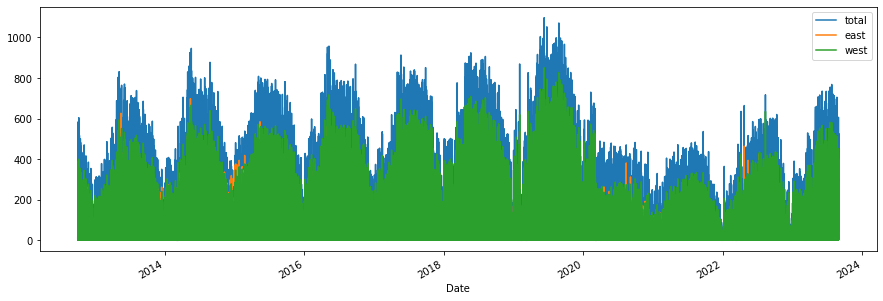

In [24]:
# plot the data
fremont.plot(figsize=(15,5))

In [25]:
#resample by day
fremont.resample('D').sum() # daily number of bikes

,total,east,west
Date,,,
2012-10-03,3521.0,1760.0,1761.0
2012-10-04,3475.0,1708.0,1767.0
2012-10-05,3148.0,1558.0,1590.0
2012-10-06,2006.0,1080.0,926.0
2012-10-07,2142.0,1191.0,951.0
...,...,...,...
2023-08-27,2169.0,936.0,1233.0
2023-08-28,3027.0,1026.0,2001.0
2023-08-29,2767.0,842.0,1925.0


<AxesSubplot:xlabel='Date'>

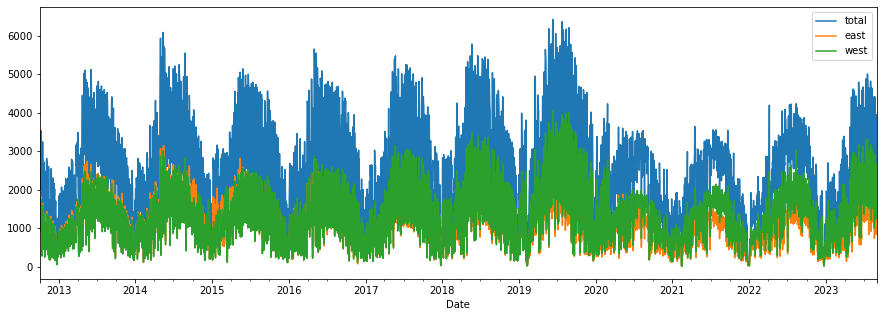

In [26]:
fremont.resample('D').sum().plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

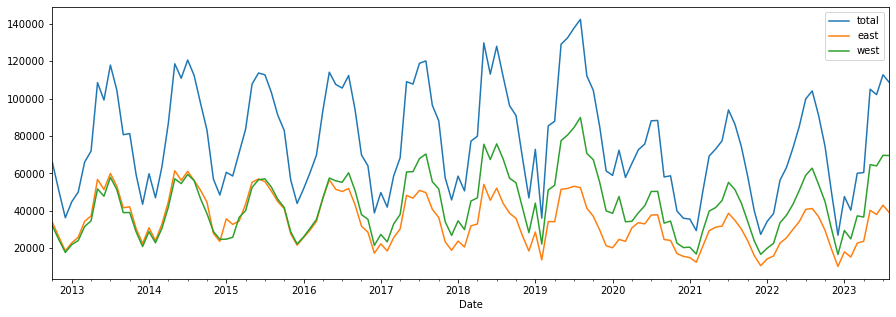

In [27]:
# resample by month
fremont.resample('M').sum().plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

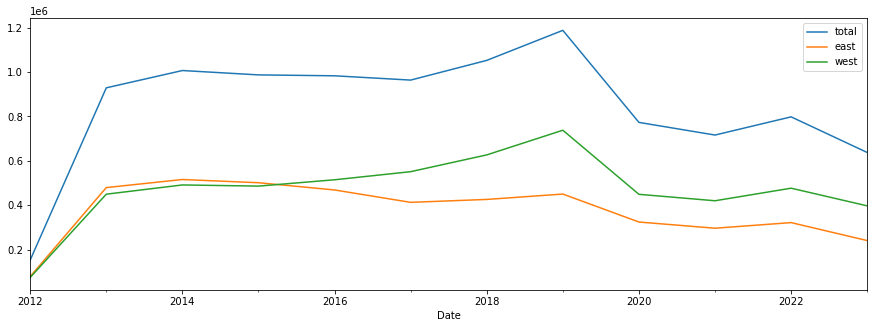

In [28]:
# resample by year
fremont.resample('Y').sum().plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

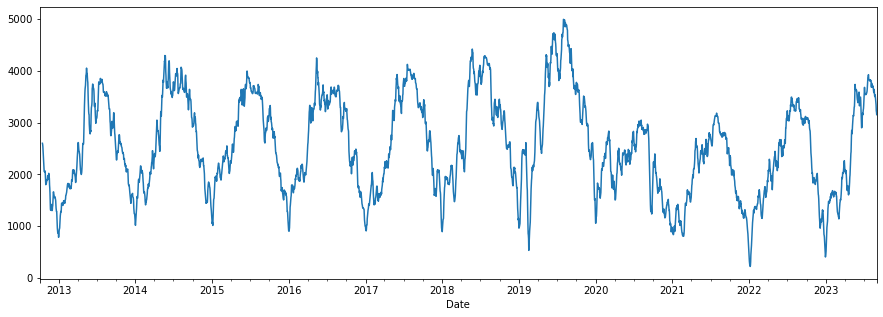

In [29]:
# rolling (moving average)
fremont.resample('D').sum().total.rolling(14).mean().plot(figsize=(15,5))

In [30]:
daily = fremont.pivot_table(values='total',index=fremont.index.time,columns=fremont.index.date)

In [31]:
daily

,2012-10-03,2012-10-04,2012-10-05,2012-10-06,2012-10-07,2012-10-08,2012-10-09,2012-10-10,2012-10-11,2012-10-12,...,2023-08-22,2023-08-23,2023-08-24,2023-08-25,2023-08-26,2023-08-27,2023-08-28,2023-08-29,2023-08-30,2023-08-31
00:00:00,13.0,18.0,11.0,15.0,11.0,9.0,12.0,15.0,21.0,17.0,...,8.0,10.0,7.0,14.0,27.0,28.0,8.0,7.0,6.0,13.0
01:00:00,10.0,3.0,8.0,15.0,17.0,4.0,3.0,3.0,10.0,13.0,...,1.0,4.0,3.0,12.0,15.0,14.0,4.0,3.0,6.0,6.0
02:00:00,2.0,9.0,7.0,9.0,3.0,5.0,4.0,3.0,13.0,5.0,...,8.0,5.0,6.0,3.0,10.0,5.0,5.0,2.0,5.0,3.0
03:00:00,5.0,3.0,4.0,3.0,6.0,5.0,8.0,4.0,2.0,7.0,...,4.0,3.0,1.0,0.0,4.0,1.0,3.0,4.0,4.0,6.0
04:00:00,7.0,8.0,9.0,5.0,3.0,5.0,9.0,5.0,12.0,5.0,...,11.0,4.0,13.0,11.0,3.0,5.0,8.0,11.0,11.0,10.0
05:00:00,31.0,26.0,25.0,5.0,9.0,23.0,31.0,25.0,12.0,14.0,...,26.0,27.0,25.0,28.0,12.0,5.0,33.0,16.0,32.0,25.0
06:00:00,155.0,142.0,105.0,27.0,17.0,137.0,153.0,149.0,43.0,87.0,...,119.0,100.0,111.0,73.0,59.0,18.0,110.0,85.0,103.0,112.0
07:00:00,352.0,319.0,319.0,33.0,26.0,327.0,368.0,340.0,304.0,183.0,...,326.0,335.0,291.0,181.0,54.0,35.0,191.0,256.0,289.0,271.0
08:00:00,437.0,418.0,370.0,105.0,69.0,457.0,462.0,435.0,404.0,268.0,...,528.0,446.0,464.0,267.0,72.0,63.0,344.0,390.0,407.0,409.0
09:00:00,276.0,241.0,212.0,114.0,103.0,278.0,275.0,255.0,189.0,145.0,...,332.0,307.0,306.0,151.0,128.0,102.0,239.0,246.0,264.0,243.0


<AxesSubplot:xlabel='time'>

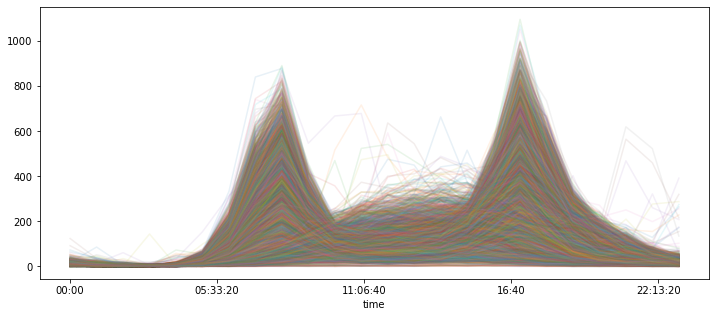

In [33]:
daily.plot(figsize=(12,5), legend=False, alpha=0.1) # alpha is the opacity

In [35]:
table = fremont.pivot_table(values='total',index=fremont.index.time,columns=fremont.index.dayofweek, aggfunc = 'mean')

<AxesSubplot:xlabel='time'>

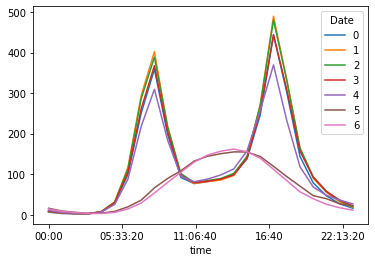

In [36]:
table.plot()

In [42]:
daily.loc[:,daily.iloc[23]>150]

,2013-07-04,2014-07-04,2015-07-04,2016-07-04,2016-07-08,2017-07-04,2017-07-07,2018-06-29,2018-07-04,2019-07-04,2022-07-04,2023-07-04
00:00:00,23.0,20.0,22.0,18.0,8.0,10.0,23.0,9.0,29.0,14.0,5.0,11.0
01:00:00,14.0,15.0,14.0,6.0,2.0,11.0,8.0,6.0,9.0,11.0,5.0,10.0
02:00:00,61.0,6.0,4.0,3.0,3.0,1.0,7.0,6.0,5.0,7.0,1.0,6.0
03:00:00,6.0,6.0,5.0,0.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0
04:00:00,4.0,9.0,3.0,3.0,4.0,8.0,5.0,11.0,7.0,4.0,6.0,14.0
05:00:00,17.0,20.0,12.0,9.0,20.0,12.0,43.0,48.0,18.0,8.0,7.0,15.0
06:00:00,32.0,27.0,39.0,30.0,122.0,31.0,164.0,121.0,35.0,40.0,22.0,26.0
07:00:00,59.0,61.0,73.0,30.0,306.0,64.0,397.0,349.0,73.0,52.0,33.0,68.0
08:00:00,108.0,126.0,136.0,59.0,392.0,99.0,542.0,474.0,161.0,115.0,68.0,122.0
09:00:00,137.0,155.0,149.0,87.0,219.0,198.0,315.0,269.0,130.0,140.0,116.0,166.0
